### **1 Multi-Class Classification: Logits, Softmax, and Cross-Entropy**


#### 1.1 Regression vs. Classification

In **regression**, the model predicts a continuous value.

Example:

```text
prediction = 3.7
```

The loss usually measures the distance between the prediction and the true value.

For example, mean squared error:

$$L = (\hat{y} - y)^2$$

In **classification**, the model predicts which class an input belongs to.

Example:

```text
cat / dog / bird
```

For a multi-class classification problem, the model outputs one score for each class.

If there are 3 classes, the model outputs 3 scores:

```text
[2.0, 1.0, 0.1]
```


#### 1.2 Logits

The raw scores produced by the model are called **logits**.

For example:

```text
logits = [2.0, 1.0, 0.1]
```

Each number corresponds to one class:

```text
class 0 score = 2.0
class 1 score = 1.0
class 2 score = 0.1
```

Logits are not probabilities.

They can be negative, and they do not need to sum to 1.

The predicted class can be chosen by taking the index of the largest logit:

$$\hat{c} = \arg\max_i o_i$$

Example:

```text
logits = [2.0, 1.0, 0.1]
```

The largest value is `2.0`, so the predicted class is class `0`.


#### 1.3 Where Do Logits Come From?

Logits are usually produced by the final layer of the model.

A simple final layer can be written as:

$$o = Wx + b$$

where:

* $x$ is the input feature vector.
* $W$ is the weight matrix.
* $b$ is the bias vector.
* $o$ is the output logits vector.

Example:

```text
x = [1.0, 2.0]
```

For 3 classes, the final layer produces 3 scores:

```text
class 0 score = 0.8 * 1.0 + 0.6 * 2.0 + 0.1 = 2.1
class 1 score = 0.2 * 1.0 + 0.4 * 2.0 - 0.3 = 0.7
class 2 score = -0.5 * 1.0 + 0.1 * 2.0 + 0.2 = -0.1
```

So the logits are:

```text
logits = [2.1, 0.7, -0.1]
```

The weights and biases are learned during training.


#### 1.4 One-Hot Labels

For multi-class classification, labels are often represented using **one-hot encoding**.

If there are 3 classes:

```text
class 0 -> [1, 0, 0]
class 1 -> [0, 1, 0]
class 2 -> [0, 0, 1]
```

Only the correct class has value `1`.

Example:

```text
true class = class 0
label = [1, 0, 0]
```


#### 1.5 Why Not Use Raw Logits as Probabilities?

Raw logits are useful for choosing the largest score, but they are not probabilities.

Example:

```text
logits = [10, 2, -1]
```

We can tell that class `0` has the highest score.

But these values cannot be interpreted as probabilities because:

* They may be negative.
* They do not sum to 1.
* They are not limited to the range $[0, 1]$.

For training classification models, it is useful to convert logits into probabilities.


#### 1.6 Softmax

**Softmax** converts logits into probabilities.

For each class $i$:

$$\hat{y}_i = \frac{e^{o_i}}{\sum_k e^{o_k}}$$

where:

* $o_i$ is the logit for class $i$.
* $\hat{y}_i$ is the predicted probability for class $i$.

Example:

```text
logits  = [2.0, 1.0, 0.1]
softmax = [0.66, 0.24, 0.10]
```

After softmax:

```text
class 0 probability = 0.66
class 1 probability = 0.24
class 2 probability = 0.10
```

The softmax output has two important properties:

* Each value is $\ge 0$.
* All values sum to 1.

Therefore, the output can be interpreted as a probability distribution.

The predicted class is the class with the largest probability:

$$\hat{c} = \arg\max_i \hat{y}_i$$

Softmax does not change the order of the scores, so:

$$\arg\max_i o_i = \arg\max_i \hat{y}_i$$


#### 1.7 Cross-Entropy Loss

After softmax, the model gives a probability for each class.

Cross-entropy loss measures how well these predicted probabilities match the true label.

The formula is:

$$L(y, \hat{y}) = - \sum_i y_i \log(\hat{y}_i)$$

where:

* $y_i$ is the true label value for class $i$.
* $\hat{y}_i$ is the predicted probability for class $i$.

Because the label is one-hot, only the correct class matters.

So the loss becomes:

$$L = -\log(\hat{y}_{\text{true class}})$$

This means:

* If the model gives high probability to the correct class, the loss is small.
* If the model gives low probability to the correct class, the loss is large.

Example:

```text
true label = [1, 0, 0]
prediction = [0.66, 0.24, 0.10]
```

The correct class is class `0`, so:

$$L = -\log(0.66)$$


#### 1.8 Intuition of Cross-Entropy

Suppose the true class is `cat`.

##### 1.8.1 Good Prediction

```text
cat probability = 0.95
loss = -log(0.95)
```

The loss is small.

##### 1.8.2 Bad Prediction

```text
cat probability = 0.05
loss = -log(0.05)
```

The loss is large.

So cross-entropy encourages the model to assign a high probability to the correct class.


#### 1.9 Softmax + Cross-Entropy Together

The standard multi-class classification pipeline is:

```text
input
  -> model
  -> logits
  -> softmax
  -> probabilities
  -> cross-entropy loss
```

**Softmax answers:** What probability does the model assign to each class?

**Cross-entropy answers:** How much probability did the model assign to the correct class?

The training goal is:

* Increase the probability of the correct class.
* Decrease the probabilities of incorrect classes.


#### 1.10 Gradient Intuition

For softmax followed by cross-entropy, the gradient with respect to each logit is:

$$\frac{\partial L}{\partial o_i} = \hat{y}_i - y_i$$

This means:

```text
gradient = predicted probability - true label
```

For the correct class:

```text
gradient = predicted probability - 1
```

If the correct class probability is too low, the model is pushed to increase that logit.

For an incorrect class:

```text
gradient = predicted probability - 0
```

If an incorrect class probability is too high, the model is pushed to decrease that logit.

So softmax + cross-entropy naturally pushes the model to:

* Make the correct class score higher.
* Make the incorrect class scores lower.


#### 1.11 PyTorch Note

In PyTorch, `nn.CrossEntropyLoss` expects raw logits, not softmax probabilities.

Example:

```python
loss_fn = nn.CrossEntropyLoss()

logits = model(x)
loss = loss_fn(logits, labels)
```

Do not apply softmax before passing logits into `nn.CrossEntropyLoss`.

This is because `nn.CrossEntropyLoss` already combines:

```text
log_softmax + negative log likelihood loss
```

in a numerically stable way.


#### **Summary: Multi-Class Classification**

For multi-class classification:

* The model outputs logits.
* Logits are raw class scores.
* Softmax converts logits into probabilities.
* Cross-entropy checks the probability assigned to the correct class.
* Training updates the model to increase the correct class probability.

**Key formulas:**

$$o = Wx + b$$

$$\hat{y}_i = \frac{e^{o_i}}{\sum_k e^{o_k}}$$

$$L(y, \hat{y}) = - \sum_i y_i \log(\hat{y}_i)$$

For one-hot labels:

$$L = -\log(\hat{y}_{\text{true class}})$$


### **2. Loss Function**


#### 2.1 L2 Loss

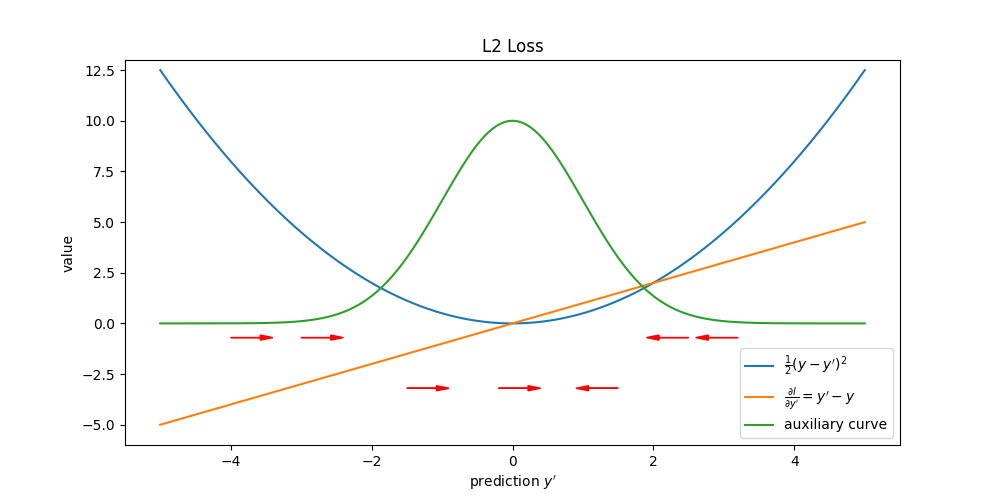


##### 2.1.1 Definition

**L2 loss** measures the squared distance between the true value and the predicted value.

$$L(y, \hat{y}) = \frac{1}{2}(y - \hat{y})^2$$

The factor $\frac{1}{2}$ is often added to make the derivative cleaner.

##### 2.1.2 Intuition

* L2 loss becomes small when the prediction is close to the target.
* L2 loss becomes large when the prediction is far away from the target.
* Because the error is squared, large errors are penalized much more strongly than small errors.

##### 2.1.3 Gradient

The gradient of L2 loss with respect to the prediction is:

$$\frac{\partial L}{\partial \hat{y}} = \hat{y} - y$$

If the target value is $y = 0$, then:

$$\frac{\partial L}{\partial \hat{y}} = \hat{y}$$

This is why the gradient looks like a straight line.

##### 2.1.4 Gradient Descent Direction

Gradient descent updates the prediction or model parameters in the negative gradient direction:

$$\hat{y} \leftarrow \hat{y} - \eta \frac{\partial L}{\partial \hat{y}}$$

where $\eta$ is the learning rate.

* If the prediction is too small, the update moves it to the right.
* If the prediction is too large, the update moves it to the left.
* In both cases, the update moves the prediction toward the minimum-loss point.

##### 2.1.5 Gaussian Distribution

The green curve represents a **Gaussian distribution**, also called a **normal distribution**.

In the context of L2 loss, it usually represents the distribution of prediction errors:

$$e = y - \hat{y}$$

We assume that the error follows a Gaussian distribution:

$$e \sim \mathcal{N}(0, \sigma^2)$$

This means most errors are close to zero, while very large errors are less likely.

The Gaussian distribution has the highest probability density near zero error and lower probability density for large positive or negative errors.

##### 2.1.6 Connection Between L2 Loss and Gaussian Noise

The probability density of a Gaussian error can be written as:

$$p(e) \propto \exp\left(-\frac{e^2}{2\sigma^2}\right)$$

The important term here is:

$$e^2$$

Since $e = y - \hat{y}$, this becomes:

$$(y - \hat{y})^2$$

Therefore, if we assume the prediction errors follow a Gaussian distribution, maximizing the likelihood of the data is equivalent to minimizing L2 loss.

In simple words:

> L2 loss naturally comes from the assumption that errors are Gaussian distributed.

##### 2.1.7 What Each Curve Means

* **Blue curve:** the L2 loss.
* **Orange line:** the gradient of the L2 loss.
* **Red arrows:** the gradient descent update direction.
* **Green curve:** the Gaussian distribution of errors.

##### 2.1.8 Pros and Cons

**Advantages:**

* Simple and easy to compute.
* Smooth and differentiable.
* Works well with gradient-based optimization.
* Has a clear connection to Gaussian noise.

**Disadvantages:**

* Sensitive to outliers.
* Large errors dominate the loss because of the square term.

#### 2.2 L1 Loss


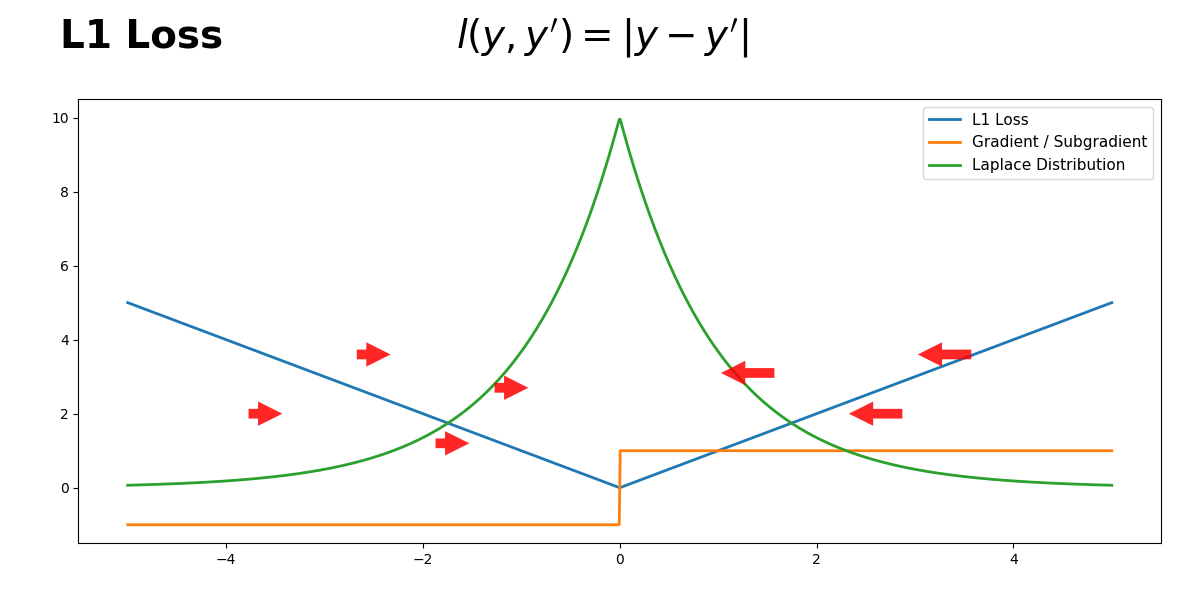

##### 2.2.1 Definition

**L1 loss** measures the absolute distance between the true value and the predicted value.

$$L(y, \hat{y}) = |y - \hat{y}|$$

It is also called **absolute error loss**.

##### 2.2.2 Intuition

* L1 loss becomes small when the prediction is close to the target.
* L1 loss becomes large when the prediction is far away from the target.
* Unlike L2 loss, L1 loss grows linearly with the error.

For example:

$$|2| = 2$$

$$|4| = 4$$

So doubling the error only doubles the loss.

##### 2.2.3 Gradient

Let the prediction error be:

$$e = \hat{y} - y$$

Then the L1 loss can be written as:

$$L = |e|$$

The gradient of L1 loss with respect to the prediction is:

$$\frac{\partial L}{\partial \hat{y}} =
\begin{cases}
-1, & \hat{y} < y \\
1, & \hat{y} > y
\end{cases}$$

At $\hat{y} = y$, L1 loss is not differentiable because the curve has a sharp corner.

In practice, we often use a subgradient at that point, commonly choosing:

$$0$$

##### 2.2.4 Gradient Descent Direction

Gradient descent updates the prediction or model parameters in the negative gradient direction:

$$\hat{y} \leftarrow \hat{y} - \eta \frac{\partial L}{\partial \hat{y}}$$

where $\eta$ is the learning rate.

* If the prediction is smaller than the target, the gradient is $-1$, so the update moves the prediction to the right.
* If the prediction is larger than the target, the gradient is $1$, so the update moves the prediction to the left.
* In both cases, the update moves the prediction toward the target.

##### 2.2.5 Laplace Distribution

The green curve represents a **Laplace distribution**.

In the context of L1 loss, it usually represents the distribution of prediction errors.

We assume that the error follows a Laplace distribution:

$$e = y - \hat{y}$$

$$e \sim \text{Laplace}(0, b)$$

This means most errors are close to zero, while larger errors are less likely.

Compared with the Gaussian distribution, the Laplace distribution has a sharper peak at zero and heavier tails.

##### 2.2.6 Connection Between L1 Loss and Laplace Noise

The probability density of a Laplace error can be written as:

$$p(e) \propto \exp\left(-\frac{|e|}{b}\right)$$

The important term here is:

$$|e|$$

Since:

$$e = y - \hat{y}$$

this becomes:

$$|y - \hat{y}|$$

Therefore, if we assume the prediction errors follow a Laplace distribution, maximizing the likelihood of the data is equivalent to minimizing L1 loss.

In simple words:

> L1 loss naturally comes from the assumption that errors are Laplace distributed.

##### 2.2.7 What Each Curve Means

* **Blue V-shaped curve:** the L1 loss.
* **Orange step-like line:** the gradient or subgradient of the L1 loss.
* **Green curve:** the Laplace distribution of errors.

##### 2.2.8 Pros and Cons

**Advantages:**

* More robust to outliers than L2 loss.
* Encourages sparse solutions in some models.
* Has a clear connection to Laplace noise.

**Disadvantages:**

* Not differentiable at zero.
* Gradient is constant away from zero.
* Optimization can be less smooth than L2 loss.


#### `2.3 Huber Loss`

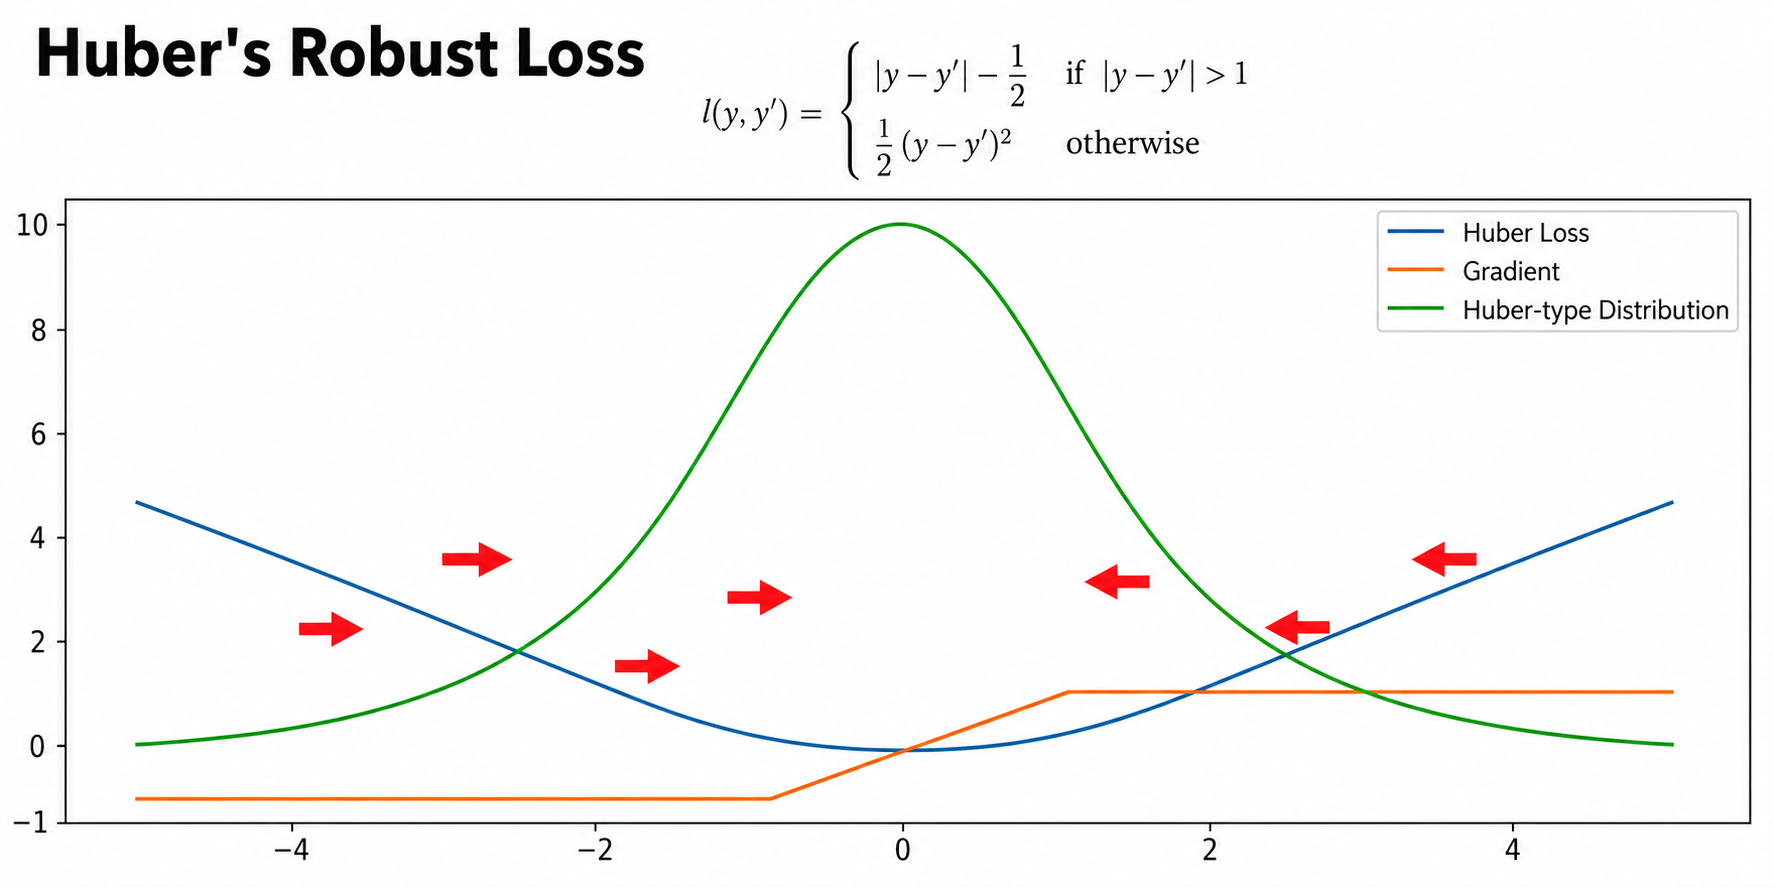

##### 2.3.1 Definition

**Huber loss** is a piecewise loss function that combines the advantages of L2 loss and L1 loss.

For a prediction error:

$$e = y - \hat{y}$$

the Huber loss with threshold $\delta$ is defined as:

$$L_\delta(e)=
\begin{cases}
\frac{1}{2}e^2, & |e| \le \delta \\
\delta \left(|e| - \frac{1}{2}\delta\right), & |e| > \delta
\end{cases}$$

In the figure, $\delta = 1$, so the loss becomes:

$$L(e)=
\begin{cases}
\frac{1}{2}e^2, & |e| \le 1 \\
|e| - \frac{1}{2}, & |e| > 1
\end{cases}$$

##### 2.3.2 Intuition

Huber loss behaves like L2 loss when the error is small, and like L1 loss when the error is large.

* Near zero error, it is quadratic.
* For large error, it becomes linear.

This makes Huber loss a good compromise:

* Smoother than L1 loss near zero.
* More robust to outliers than L2 loss.

##### 2.3.3 Why It Is Called Robust Loss

L2 loss squares the error, so very large errors can dominate the training process.

L1 loss is more robust to outliers, but it is not differentiable at zero.

Huber loss keeps the smooth behavior of L2 loss for small errors, while avoiding excessive penalty for large errors.

That is why it is often called a **robust loss**.

##### 2.3.4 Gradient

If we define the prediction-side error as:

$$r = \hat{y} - y$$

then the gradient of Huber loss with respect to $\hat{y}$ is:

$$\frac{\partial L}{\partial \hat{y}}=
\begin{cases}
-1, & r < -1 \\
r, & |r| \le 1 \\
1, & r > 1
\end{cases}$$

So the gradient:

* Is linear near zero.
* Is clipped to a constant value for large errors.

This means the gradient will not grow without bound.

##### 2.3.5 Gradient Descent Direction

Gradient descent updates the prediction or model parameters in the negative gradient direction:

$$\hat{y} \leftarrow \hat{y} - \eta \frac{\partial L}{\partial \hat{y}}$$

where $\eta$ is the learning rate.

* If the prediction is too small, the update moves it to the right.
* If the prediction is too large, the update moves it to the left.
* Near the target, the update becomes smoother because the gradient changes continuously.

##### 2.3.6 Connection to Error Distribution

Huber loss can be interpreted as being associated with an error model that is:

* Gaussian-like near zero.
* Laplace-like in the tails.

This means:

* Small errors are treated like L2 loss.
* Large errors are treated more like L1 loss.

The green curve in the figure can be understood as a Huber-type error distribution: a sharp central peak with heavier tails than a pure Gaussian.

##### 2.3.7 What Each Curve Means

* **Blue curve:** the Huber loss.
* **Orange curve:** the gradient of the Huber loss.
* **Green curve:** a Huber-type error distribution.
* **Red arrows:** the gradient descent update direction.

##### 2.3.8 Pros and Cons

**Advantages:**

* Combines benefits of L1 and L2.
* Smooth near zero.
* More robust to outliers than L2 loss.
* Prevents very large gradients from large errors.

**Disadvantages:**

* Requires choosing a threshold $\delta$.
* Slightly more complex than L1 or L2.
* Performance depends on the choice of $\delta$.


### **3 Image Classification Dataset**


We use the **Fashion-MNIST** dataset, which is more complex than the original MNIST dataset.


In [31]:
%matplotlib inline
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
from d2l import torch as d2l

d2l.use_svg_display()

Use built-in framework utilities to download the Fashion-MNIST dataset and load it into memory.


In [32]:
# Use ToTensor to convert PIL images into 32-bit floating-point tensors.
# It also divides pixel values by 255, so all pixel values are in the range [0, 1].
trans=transforms.ToTensor()
mnist_train=torchvision.datasets.FashionMNIST(root="../data",train=True,
                                              transform=trans,
                                              download=True)
mnist_test=torchvision.datasets.FashionMNIST(root="../data",train=False,
                                             transform=trans,download=True)

len(mnist_train),len(mnist_test)


(60000, 10000)

In [33]:
mnist_train[0][0].shape

torch.Size([1, 28, 28])

In [34]:
# Helper functions for visualizing the dataset
def get_fasion_mnist_labels(labels):
    """Return text labels for Fashion-MNIST classes"""
    text_laels=[
        't-shirt','trouser','pullover','dress','coat',
        'scandal','shirt','sneaker','bag','ankle boot']
    return [text_laels[int(i)] for i in labels]

def show_image(imgs,num_rows,num_cols,titles=None,scale=1.5):
    """Plot a list of images"""
    figsize=(num_cols*scale,num_rows*scale)
    _,axes=d2l.plt.subplots(num_rows,num_cols,figsize=figsize)
    axes=axes.flatten()
    for i, (ax,img) in enumerate(zip(axes,imgs)):
        if torch.is_tensor(img):
            ax.imshow(img.numpy())
        else:
            ax.imshow(img)

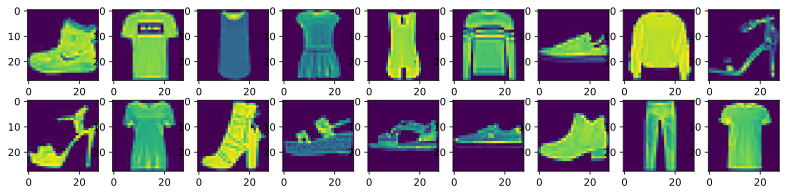

In [35]:
x,y=next(iter(data.DataLoader(mnist_train,batch_size=18)))
show_image(x.reshape(18,28,28),2,9,titles=get_fasion_mnist_labels)

In [36]:
# Read a small set of data, size=batch_size

batch_size=256

def get_dataloader_workers():
    """Use 4 worker processes to read the data."""
    return 4

train_iter=data.DataLoader(mnist_train,batch_size,shuffle=True,
                           num_workers=get_dataloader_workers())

timer=d2l.Timer()
for x,y in train_iter:
    continue
f'{timer.stop():.2f} sec'

'0.71 sec'

In [37]:
# Define load_data_fashion_mnist function
def load_data_fashion_mnist(batch_size,resize=None):
    """Download the Fashion-MNIST Dataset and load it to storage"""
    trans=[transforms.ToTensor()]
    if resize:
        trans.insert(0,transforms.Resize(resize))
    trans=transforms.Compose(trans)
    mnist_train=torchvision.datasets.FashionMNIST(root="../data",
                                                  train=True,
                                                  transform=trans,
                                                  download=True)
    mnist_test=torchvision.datasets.FashionMNIST(root="../data",
                                                  train=True,
                                                  transform=trans,
                                                  download=True)
    return (data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=get_dataloader_workers()))
    

### **4 Implementation of Softmax from scratch**


#### Line-by-Line Review: Manual Softmax

- `import torch`: loads PyTorch tensors and autograd.
- `from IPython import display`: lets the notebook update plots in place.
- `from d2l import torch as d2l`: imports D2L helper functions.
- `batch_size = 256`: uses 256 examples per mini-batch.
- `train_iter, test_iter = ...`: loads Fashion-MNIST data iterators.
- `num_inputs = 784`: flattens each `28 x 28` image into 784 features.
- `num_outputs = 10`: predicts one of 10 classes.
- `w = ...`: creates trainable weights with small random values.
- `b = ...`: creates trainable bias values initialized to zero.
- `x.sum(...)`: demonstrates summing by rows or columns.
- `softmax(x)`: exponentiates logits, sums each row, then normalizes each row into probabilities.
- `net(x)`: flattens images, applies the linear layer manually, then applies softmax.
- `cross_entropy(...)`: selects the predicted probability for the true class and returns `-log(probability)`.
- `accuracy(...)`: compares predicted labels with true labels and counts correct predictions.
- `evaluate_accuracy(...)`: accumulates correct predictions and total examples on a dataset.
- `Accumulator`: stores running sums such as loss, correct predictions, and number of examples.
- `train_epoch_ch3(...)`: runs one training pass over all mini-batches.
- `Animator`: updates the training plot after each epoch.
- `train_ch3(...)`: repeats training for multiple epochs and plots train/test metrics.
- `updater(...)`: applies mini-batch SGD to `w` and `b`.
- `predict_ch3(...)`: displays images with true and predicted labels.



In [38]:
import torch
from IPython import display
from d2l import torch as d2l

batch_size=256
train_iter,test_iter=d2l.load_data_fashion_mnist(batch_size)

In [39]:
# Flatten each image and treat it as a 784-dimensional vector.
# The dataset has 10 classes, so the network has 10 outputs.
num_inputs=784
num_outputs=10

w=torch.normal(0,0.01,size=(num_inputs,num_outputs), requires_grad=True)
b=torch.zeros(num_outputs,requires_grad=True)

In [40]:
# Given a matrix x, sum its elements along different axes.
x=torch.tensor([[1.0,2.0,3.0],[4.0,5.0,6.0]])
x.sum(0,keepdim=True),x.sum(1,keepdim=True)

(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))

Implementation of softmax:
$$\text{softmax}(\mathbf{X})_{ij} = \frac{\exp(\mathbf{X}_{ij})}{\sum_k \exp(\mathbf{X}_{ik})}$$

In [41]:
def softmax(x):
    x_exp=torch.exp(x)
    partition=x_exp.sum(1,keepdim=True)
    return x_exp/partition # Use broadcasting for row-wise division.

In [42]:
x=torch.normal(0,1,(2,5))
x_prob=softmax(x)
x_prob,x_prob.sum(1)

(tensor([[0.3479, 0.3515, 0.0154, 0.0452, 0.2401],
         [0.1126, 0.1413, 0.0207, 0.3320, 0.3934]]),
 tensor([1., 1.]))

In [43]:
# Softmax Regression Model
def net(x):
    return softmax(torch.matmul(x.reshape((-1,w.shape[0])),w)+b) 

In [44]:
# Create y_hat with predicted probabilities for 2 samples over 3 classes; use y to index the true-class probabilities.
y=torch.tensor([0,2])
y_hat=torch.tensor([[0.1,0.3,0.6],[0.3,0.2,0.5]])
y_hat[[0,1],y]

tensor([0.1000, 0.5000])

In [45]:
# Implement the cross-entropy loss function.
def cross_entropy(y_hat,y):
    return -torch.log(y_hat[range(len(y_hat)),y])

cross_entropy(y_hat,y)

tensor([2.3026, 0.6931])

In [46]:
# Compare predicted classes with the true labels in y.
def accuracy(y_hat,y):
    """Count the number of correct predictions."""
    if len(y_hat.shape)>1 and y_hat.shape[1]>1:
        y_hat=y_hat.argmax(axis=1)
    cmp=y_hat.type(y.dtype)==y
    return float(cmp.type(y.dtype).sum())

accuracy(y_hat,y)/len(y)

0.5

In [47]:
# Evaluate the accuracy of any model net.
def evaluate_accuracy(net,data_iter):
    """Compute model accuracy on a given dataset."""
    if isinstance(net,torch.nn.Module):
        net.eval()  # Set the model to evaluation mode.
    metric=Accumulator(2)   # Number of correct predictions and total predictions.
    for x,y in data_iter:
        metric.add(accuracy(net(x),y),y.numel())
    return metric[0]/metric[1]

In [48]:
# Create an Accumulator instance to store running totals.
class Accumulator:
    """Accumulate values over n variables."""
    def __init__(self,n):
        self.data=[0.0]*n
    
    def add(self,*args):
        self.data=[a+float(b) for a,b in zip(self.data,args)]
    
    def reset(self):
        self.data=[0.0]*len(self.data)

    def __getitem__(self,idx):
        return self.data[idx]
    
evaluate_accuracy(net,test_iter)

0.0877

In [49]:
# Softmax Regression Training
def train_epoch_ch3(net,train_iter,loss,updater):
    if isinstance(net,torch.nn.Module):
        net.train()
    metric=Accumulator(3)
    for x,y in train_iter:
        y_hat=net(x)
        l=loss(y_hat,y)
        if isinstance(updater,torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            updater.step()
            metric.add(
                float(l)*len(y),accuracy(y_hat,y),
                y.size().numel())
        else:
            l.sum().backward()
            updater(x.shape[0])
            metric.add(float(l.sum()),accuracy(y_hat,y),y.numel())
    return metric[0]/metric[2],metric[1]/metric[2]

In [50]:
# Define a utility class for plotting data with live updates.
class Animator:  #@save
    """Plot data with live updates."""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # Plot multiple lines incrementally.
        if legend is None:
            legend = []
        d2l.use_svg_display()
        self.fig, self.axes = d2l.plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # Use a lambda function to capture plotting parameters.
        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # Add multiple data points to the chart.
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

In [51]:
# Training function.
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):  #@save
    """Train a model, following the Chapter 3 style."""
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics

In [52]:
# Use mini-batch stochastic gradient descent to optimize the model loss.
lr = 0.1

def updater(batch_size):
    return d2l.sgd([w, b], lr, batch_size)

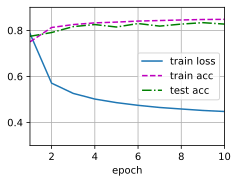

In [53]:
# Train the model for 10 epochs.
num_epochs = 10
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

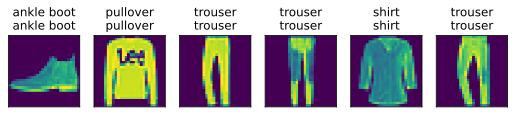

In [54]:
# Predict image classes.
def predict_ch3(net, test_iter, n=6):  #@save
    """Predict labels."""
    for X, y in test_iter:
        break
    trues = d2l.get_fashion_mnist_labels(y)
    preds = d2l.get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    d2l.show_images(
        X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])

predict_ch3(net, test_iter)

### **5 Simplified Implementation of Softmax**

#### Line-by-Line Review: Concise Softmax

- `import torch`: loads PyTorch.
- `from torch import nn`: imports neural-network layers and losses.
- `from d2l import torch as d2l`: imports D2L data and plotting helpers.
- `batch_size = 256`: sets the mini-batch size.
- `train_iter, test_iter = ...`: loads Fashion-MNIST data.
- `nn.Sequential(...)`: builds the model as a stack of layers.
- `nn.Flatten()`: converts each image from `28 x 28` to a 784-value vector.
- `nn.Linear(784, 10)`: maps 784 input features to 10 class logits.
- `init_weights(m)`: initializes linear-layer weights with small random values.
- `net.apply(init_weights)`: applies the initializer to the model.
- `nn.CrossEntropyLoss()`: combines softmax and cross-entropy loss internally, so the model should output raw logits.
- `torch.optim.SGD(...)`: creates the SGD optimizer for all model parameters.
- `num_epochs = 10`: trains for 10 complete passes over the data.
- `train_ch3(...)`: reuses the earlier training loop to train and evaluate the concise model.



In [55]:
import torch
from torch import nn
from d2l import torch as d2l

batch_size=256
train_iter,test_iter=d2l.load_data_fashion_mnist(batch_size)

In [56]:
# The output layer of softmax regression is a fully connected layer.
# Add a Flatten layer before the linear layer to reshape the input.
net=nn.Sequential(nn.Flatten(),nn.Linear(784,10))

def init_weights(m):
    if type(m)==nn.Linear:
        nn.init.normal_(m.weight,std=0.01)
net.apply(init_weights);

In [57]:
# CrossEntropyLoss takes raw logits and computes softmax plus log loss internally.
loss=nn.CrossEntropyLoss()

In [58]:
# Use mini-batch SGD with a learning rate of 0.1 as the optimizer.
trainer=torch.optim.SGD(net.parameters(),lr=0.1)

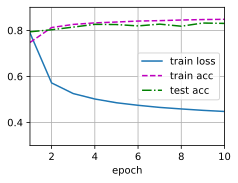

In [59]:
# Call the previously defined training function to train the model.
num_epochs=10
train_ch3(net,train_iter,test_iter,loss,num_epochs,trainer)